In [1]:
# Домашнее задание 01: настройка инструментов\n"
# Этот ноутбук проверяет работоспособность окружения и знакомит с базовыми операциями NumPy, Pandas, визуализации и Scikit-learn.

In [2]:
## 1. Проверка окружения\n"
# Выводим версии Python и основных библиотек.

In [3]:
import sys
import numpy as np
import pandas as pd
import sklearn
import matplotlib
import seaborn as sns

print("Python version:", sys.version)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("scikit-learn version:", sklearn.__version__)
print("Matplotlib version:", matplotlib.__version__)
print("Seaborn version:", sns.__version__)

Python version: 3.13.12 | packaged by Anaconda, Inc. | (main, Feb 24 2026, 16:05:56) [MSC v.1942 64 bit (AMD64)]
NumPy version: 2.4.4
Pandas version: 3.0.1
scikit-learn version: 1.8.0
Matplotlib version: 3.10.8
Seaborn version: 0.13.2


In [4]:
### 2.1 Создаём случайную матрицу X (100×5)

In [5]:
# Фиксируем seed для воспроизводимости
np.random.seed(42)

X = np.random.randn(100, 5)  # 100 строк, 5 столбцов
print("Форма X:", X.shape)

Форма X: (100, 5)


In [6]:
### 2.2 Статистики для всей матрицы и по столбцами

In [7]:
print("Статистики для всей матрицы:")
print(f"  mean = {np.mean(X):.4f}")
print(f"  std  = {np.std(X):.4f}")
print(f"  min  = {np.min(X):.4f}")
print(f"  max  = {np.max(X):.4f}")

print("\nСтатистики по столбцам (axis=0):")
for i in range(X.shape[1]):
    print(f"Столбец {i}: mean={np.mean(X[:, i]):.4f}, std={np.std(X[:, i]):.4f}, min={np.min(X[:, i]):.4f}, max={np.max(X[:, i]):.4f}")

Статистики для всей матрицы:
  mean = 0.0068
  std  = 0.9803
  min  = -3.2413
  max  = 3.8527

Статистики по столбцам (axis=0):
Столбец 0: mean=-0.0447, std=0.8958, min=-1.9521, max=2.3147
Столбец 1: mean=0.0770, std=0.9792, min=-2.3019, max=1.8862
Столбец 2: mean=-0.0939, std=0.9790, min=-3.2413, max=2.1222
Столбец 3: mean=0.1281, std=0.9547, min=-1.9133, max=3.0789
Столбец 4: mean=-0.0322, std=1.0674, min=-2.6197, max=3.8527


In [8]:
### 2.3 Векторизация: линейная комбинация y = X @ w

In [9]:
# Случайный вектор весов w (5 элементов)
w = np.random.randn(5)

# Векторизованное умножение матрицы на вектор
y = X @ w

print("Форма y:", y.shape)
print("Первые 5 значений y:", y[:5])

Форма y: (100,)
Первые 5 значений y: [ 0.29997426  1.10790121 -1.61169274 -2.48647552  0.38401638]


In [10]:
## 3. Pandas

### 3.1 Создаём DataFrame из X с осмысленными названиями колонок

In [11]:
column_names = [f"feature_{i}" for i in range(1, X.shape[1] + 1)]
df = pd.DataFrame(X, columns=column_names)
df["target"] = y

print("Первые 5 строк:")
display(df.head())
print(f"\nРазмер DataFrame: {df.shape}")
print("\nСтатистика:")
display(df.describe())
print("\nПропуски:")
display(df.isnull().sum())

Первые 5 строк:


,feature_1,feature_2,feature_3,feature_4,feature_5,target
0,0.496714,-0.138264,0.647689,1.523030,-0.234153,0.299974
1,-0.234137,1.579213,0.767435,-0.469474,0.542560,1.107901
2,-0.463418,-0.465730,0.241962,-1.913280,-1.724918,-1.611693
3,-0.562288,-1.012831,0.314247,-0.908024,-1.412304,-2.486476
4,1.465649,-0.225776,0.067528,-1.424748,-0.544383,0.384016



Размер DataFrame: (100, 6)

Статистика:


,feature_1,feature_2,feature_3,feature_4,feature_5,target
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,-0.044747,0.076954,-0.093874,0.128058,-0.032202,0.329827
std,0.900352,0.984110,0.983943,0.959556,1.072806,2.384851
min,-1.952088,-2.301921,-3.241267,-1.913280,-2.619745,-6.468968
25%,-0.734897,-0.678136,-0.700307,-0.536288,-0.757046,-1.088298
50%,-0.010110,0.066421,-0.024662,0.152465,-0.145714,0.324026
75%,0.524237,0.830645,0.532419,0.667929,0.648170,1.935344
max,2.314659,1.886186,2.122156,3.078881,3.852731,5.906938



Пропуски:


feature_1    0
feature_2    0
feature_3    0
feature_4    0
feature_5    0
target       0
dtype: int64

In [12]:
 ### 3.2 Осмысленные операции: фильтрация, сортировка, groupby

In [13]:
# Фильтрация: строки, где target больше среднего
mean_target = df["target"].mean()
filtered = df[df["target"] > mean_target]
print(f"Строк с target > среднего ({mean_target:.4f}): {len(filtered)}")

# Сортировка по target (по убыванию)
sorted_df = df.sort_values(by="target", ascending=False)
print("\nПервые 5 строк после сортировки по target:")
display(sorted_df.head())

# Группировка: разбиваем target на 3 категории и считаем средние по признакам
df["target_cat"] = pd.cut(df["target"], bins=3, labels=["low", "medium", "high"])
grouped = df.groupby("target_cat")[column_names].mean()
print("\nСредние значения признаков по категориям target:")
display(grouped)

Строк с target > среднего (0.3298): 50

Первые 5 строк после сортировки по target:


,feature_1,feature_2,feature_3,feature_4,feature_5,target
14,0.361396,1.538037,-0.035826,1.564644,-2.619745,5.906938
84,2.060748,1.755341,-0.248964,0.971571,0.645376,5.735544
28,0.227460,1.307143,-1.607483,0.184634,0.259883,4.889575
64,0.096996,0.595157,-0.818221,2.092387,-1.006017,4.203083
87,0.074095,1.628616,-1.380101,-1.703382,-0.055548,4.185685



Средние значения признаков по категориям target:


,feature_1,feature_2,feature_3,feature_4,feature_5
target_cat,,,,,
low,0.000772,-0.991655,0.577510,-0.265209,0.780296
medium,-0.200108,-0.062739,0.016140,0.164893,-0.126757
high,0.217321,0.867364,-0.631257,0.257163,-0.265100


In [14]:
## 4. Визуализация

### 4.1 Гистограмма одного признака или target

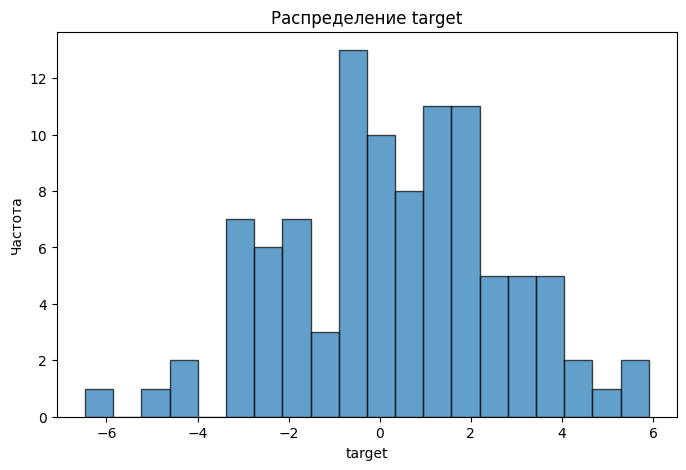

In [15]:
%matplotlib inline
import matplotlib.pyplot as plt

# Гистограмма target
plt.figure(figsize=(8, 5))
plt.hist(df["target"], bins=20, edgecolor='black', alpha=0.7)
plt.title("Распределение target")
plt.xlabel("target")
plt.ylabel("Частота")
plt.show()

In [16]:
### 4.2 Тепловая карта корреляций

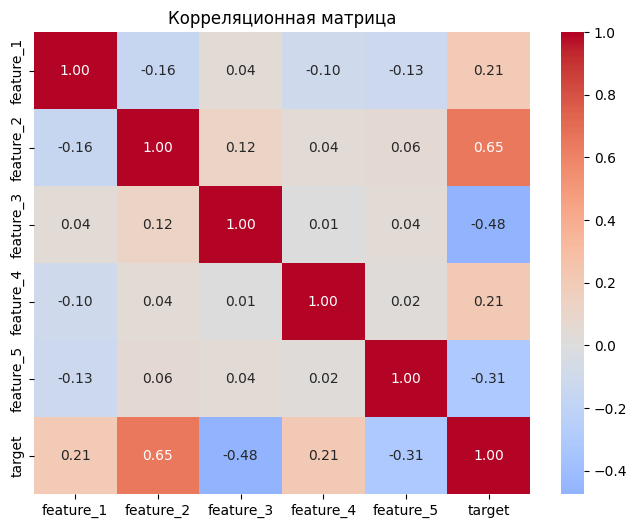

In [17]:
plt.figure(figsize=(8, 6))
corr_matrix = df[column_names + ["target"]].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Корреляционная матрица")
plt.show()

In [18]:
## 5. Бонус: Iris dataset

In [19]:
### 5.1 Загрузка данных и создание DataFrame

In [20]:
from sklearn.datasets import load_iris

iris = load_iris()
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
df_iris["target"] = iris.target
df_iris["target_name"] = iris.target_names[iris.target]

print("Первые 5 строк Iris:")
display(df_iris.head())
print(f"\nРазмер: {df_iris.shape}")
print("\nСтатистика:")
display(df_iris.describe())

Первые 5 строк Iris:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa



Размер: (150, 6)

Статистика:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [21]:
### 5.2 Визуализация распределения классов

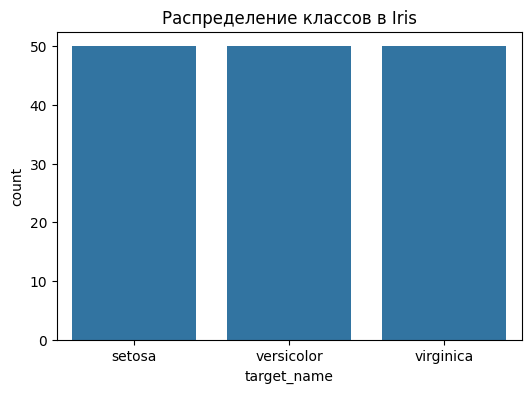

In [22]:
plt.figure(figsize=(6, 4))
sns.countplot(x="target_name", data=df_iris)
plt.title("Распределение классов в Iris")
plt.show()

In [23]:
### 5.3 Обучение простой модели и оценка accuracy

Точность (accuracy) на тесте: 0.9667


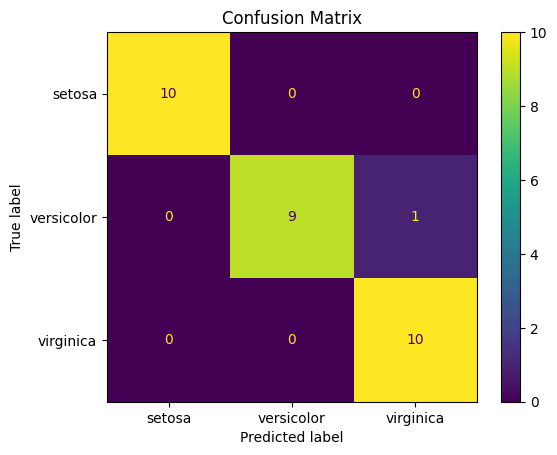

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Признаки и целевая переменная
X_iris = df_iris[iris.feature_names]
y_iris = df_iris["target"]

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris)

# Обучение модели
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# Предсказание и accuracy
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"Точность (accuracy) на тесте: {acc:.4f}")

# Можно также вывести матрицу ошибок
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot()
plt.title("Confusion Matrix")
plt.show()